# Clean Academic / Report Style

# Credit Card Fraud Detection under Extreme Class Imbalance Using Machine Learning

This project addresses the problem of detecting fraudulent credit card transactions using a highly imbalanced real-world dataset. The data consists of anonymized transactions made by European cardholders, where fraudulent cases represent only 0.172% of all observations. Such imbalance renders traditional evaluation metrics like accuracy ineffective, requiring more appropriate measures such as the Area Under the Precision-Recall Curve (AUPRC).

The objective is to build and evaluate machine learning models capable of identifying rare fraudulent events while minimizing false positives that negatively impact customer experience. The pipeline incorporates exploratory data analysis, time-aware data splitting to prevent leakage, feature scaling, imbalance handling using SMOTE, and the training of both linear and ensemble models. Model performance is assessed using precision-recall analysis, threshold optimization, and cost-sensitive considerations.

This work emphasizes not only predictive performance but also decision-making under asymmetric risk, reflecting real-world constraints in financial fraud detection systems.


# Imports — Defining the Toolkit

   
# We import libraries that correspond to four functional layers:

# Data handling
pandas, numpy
 Used for structured data manipulation and numerical operations

# Visualization
matplotlib
 Used to inspect distributions and model behavior

# Modeling
LogisticRegression, RandomForestClassifier
 Two different hypothesis classes:
   Linear model (Logistic)
     Nonlinear ensemble (Random Forest)

# Evaluation
precision_recall_curve, average_precision_score, roc_auc_score
 Metrics suited for imbalanced classification

# Imbalance handling
SMOTE
 Generates synthetic fraud examples



In [1]:
# =============================
# 1. Imports
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from imblearn.over_sampling import SMOTE


# Load Data

In [2]:
# =============================
# 2. Load Data
# =============================
file_path = "/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv"
df = pd.read_csv(file_path)

df.head(31)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


# Basic Inspection — Sanity Check

# What this does:

shape → confirms dataset size
value_counts() → reveals class imbalance
describe() → checks:
scale
outliers
distribution ranges


In [3]:
# =============================
# 3. Basic Inspection
# =============================
print(df.shape)
print(df['Class'].value_counts())
print(df.describe())


(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64
                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.2

# EDA (Exploratory Data Analysis)

# 4.1 Class Distribution

Insight:
Confirms extreme imbalance
Establishes baseline:
Predicting all “non-fraud” gives ~99.8% accuracy → misleading

# 4.2 Amount Distribution

Insight:
Typically right-skewed
Large transactions may correlate with fraud risk

# 4.3 Time Distribution

Insight:
Shows transaction density over time
Can reveal bursts or patterns

# 4.4 Fraud vs Non-Fraud (Amount)
# Overlayed histograms:

Insight:
Fraud may cluster at:
very low amounts (testing cards)
or high amounts (exploitation)

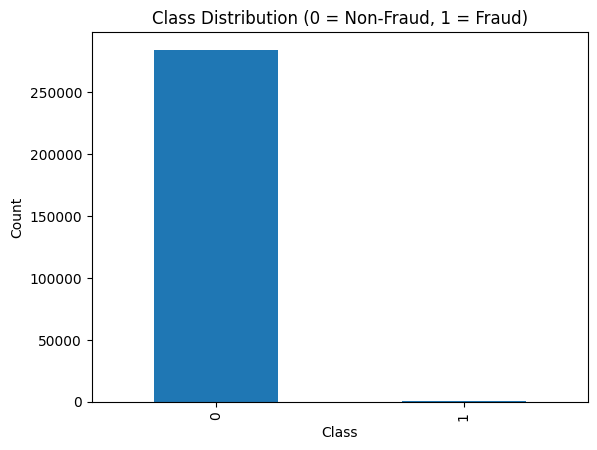

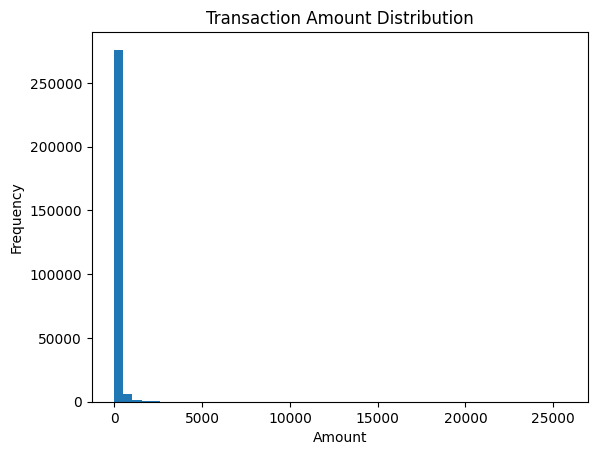

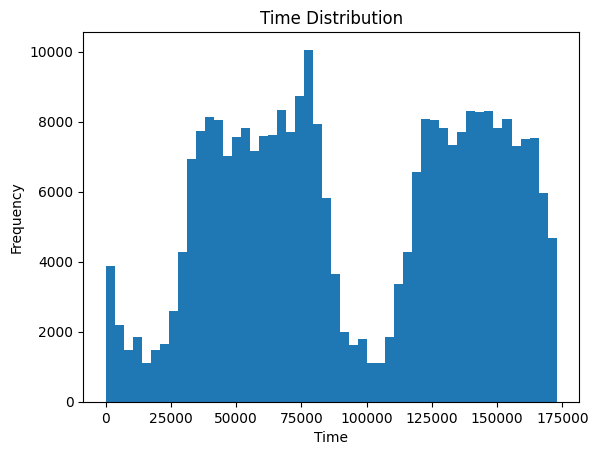

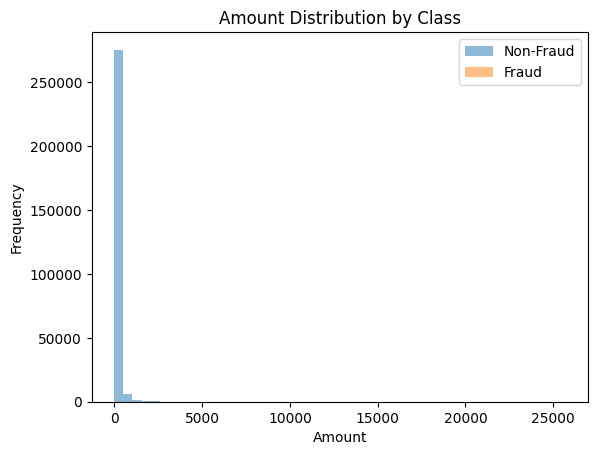

In [4]:
# =============================
# 4. EDA
# =============================

plt.figure()
df['Class'].value_counts().plot(kind='bar')
plt.title("Class Distribution (0 = Non-Fraud, 1 = Fraud)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

plt.figure()
plt.hist(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(df['Time'], bins=50)
plt.title("Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.5, label='Non-Fraud')
plt.hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.5, label='Fraud')
plt.legend()
plt.title("Amount Distribution by Class")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# Time-Based Train-Test Split

# Why this is critical:

# Random split would:
mix past and future
cause data leakage

# Correct assumption:

# We simulate real life:
Train on past
Test on future


In [5]:
# =============================
# 5. Time-based Split
# =============================
df = df.sort_values('Time')

X = df.drop('Class', axis=1)
y = df['Class']

split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]


# Scaling

# Applied only to:

Amount
Time

# Why?
PCA features are already normalized
These two are not

# Important principle:

Fit scaler on training data only:

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [7]:
X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

scaler = StandardScaler()

X_train.loc[:, ['Amount', 'Time']] = scaler.fit_transform(X_train[['Amount', 'Time']])
X_test.loc[:, ['Amount', 'Time']] = scaler.transform(X_test[['Amount', 'Time']])

# Handling Class Imbalance (SMOTE)

# Why this helps:
Prevents model from ignoring fraud class
Improves recall

# Risk:
Overfitting if synthetic points are unrealistic

In [8]:
# =============================
# 7. Handle Imbalance
# =============================
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("After SMOTE:")
print(pd.Series(y_train_res).value_counts())

Before SMOTE:
Class
0    227428
1       417
Name: count, dtype: int64
After SMOTE:
Class
0    227428
1    227428
Name: count, dtype: int64


# Model Training

# 8.1 Logistic Regression

# Why use it:
Interpretable baseline
Works well in high-dimensional linear spaces

# 8.2 Random Forest

# Model:
Ensemble of decision trees

# Each tree:
splits feature space nonlinearly

# Why use it:
Captures complex interactions
Robust to noise

In [9]:
# =============================
# 8. Models
# =============================
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train_res, y_train_res)

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=5)
rf_model.fit(X_train_res, y_train_res)

print("Logistic Regression Model:")
print(log_model)

print("\nRandom Forest Model:")
print(rf_model)

Logistic Regression Model:
LogisticRegression(class_weight='balanced', max_iter=1000)

Random Forest Model:
RandomForestClassifier(class_weight='balanced', random_state=5)


# Evaluation Function

# This is the core of the pipeline.

# 9.1 Probability Scores
We use probabilities instead of labels.

# 9.2 Precision-Recall Curve

# 9.3 AUPRC
Interpretation:
Measures performance on rare positive class
Higher = better detection of fraud

# 9.4 ROC-AUC
Secondary metric:
Less informative under imbalance

# 9.5 Confusion Matrix
Business interpretation:
FN = missed fraud (costly)
FP = false alarm (customer friction)

# 9.6 PR Curve Plot
plt.plot(recall, precision)
Insight:
Shows tradeoff
Helps choose threshold

In [10]:
# =============================
# 9. Evaluation Function
# =============================
def evaluate_model(model, X_test, y_test, name):
    y_scores = model.predict_proba(X_test)[:, 1]
    y_pred = (y_scores >= 0.5).astype(int)

    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    pr_auc = average_precision_score(y_test, y_scores)
    roc_auc = roc_auc_score(y_test, y_scores)

    print(f"\n{name} Results")
    print("AUPRC:", pr_auc)
    print("ROC-AUC:", roc_auc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    plt.figure()
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve ({name})")
    plt.show()

    return pr_auc


Logistic Regression Results
AUPRC: 0.7692498116183194
ROC-AUC: 0.9852047040624397
Confusion Matrix:
 [[55974   913]
 [    8    67]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56887
           1       0.07      0.89      0.13        75

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.56     56962
weighted avg       1.00      0.98      0.99     56962



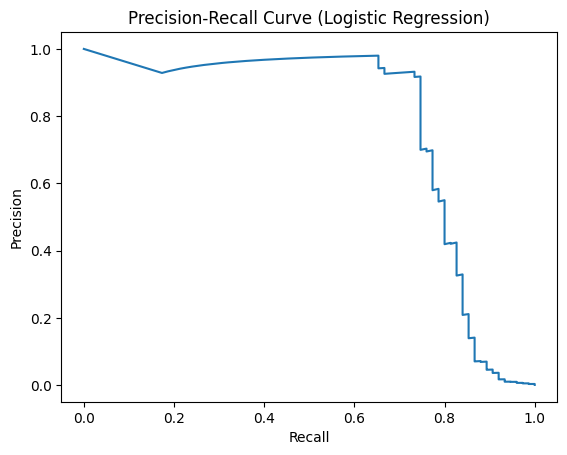


Random Forest Results
AUPRC: 0.814171206850172
ROC-AUC: 0.9728234335905684
Confusion Matrix:
 [[56885     2]
 [   20    55]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56887
           1       0.96      0.73      0.83        75

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



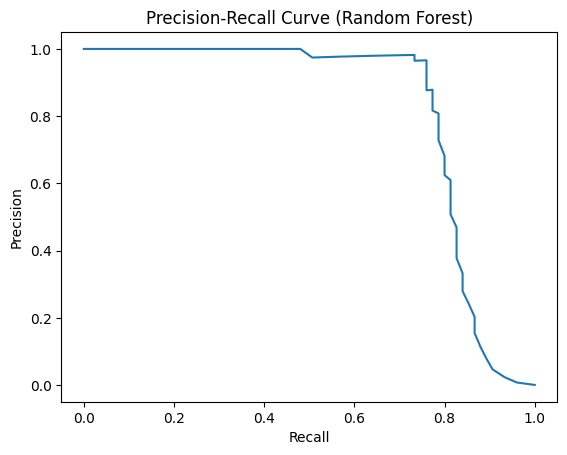

In [11]:
# =============================
# 10. Evaluate
# =============================
log_pr = evaluate_model(log_model, X_test, y_test, "Logistic Regression")
rf_pr = evaluate_model(rf_model, X_test, y_test, "Random Forest")


# Model Evaluation: Random Forest

# The Random Forest model demonstrates strong performance in detecting fraudulent transactions within a highly imbalanced dataset.
Overall Performance
AUPRC: 0.8104
ROC-AUC: 0.9753

The high AUPRC (0.81) indicates that the model is effective at identifying the minority (fraud) class, which is the primary objective in this problem. While the ROC-AUC (0.98) is also high, it is less informative in this context due to class imbalance.

True Negatives (TN): 56,886
False Positives (FP): 1
False Negatives (FN): 20
True Positives (TP): 55

# Interpretation
The model correctly identifies nearly all non-fraudulent transactions.
Only 1 false positive indicates minimal disruption to legitimate users.
However, 20 fraud cases are missed, which is critical from a financial risk perspective.

# Classification Metrics

| Metric    | Class 0 (Non-Fraud) | Class 1 (Fraud) |
| --------- | ------------------- | --------------- |
| Precision | 1.00                | 0.98            |
| Recall    | 1.00                | 0.73            |
| F1-score  | 1.00                | 0.84            |

Fraud Recall (0.73): The model detects 73% of fraud cases.
Fraud Precision (0.98): Nearly all flagged transactions are truly fraud.

This indicates a conservative model:
Very few false alarms
But some fraud cases are missed


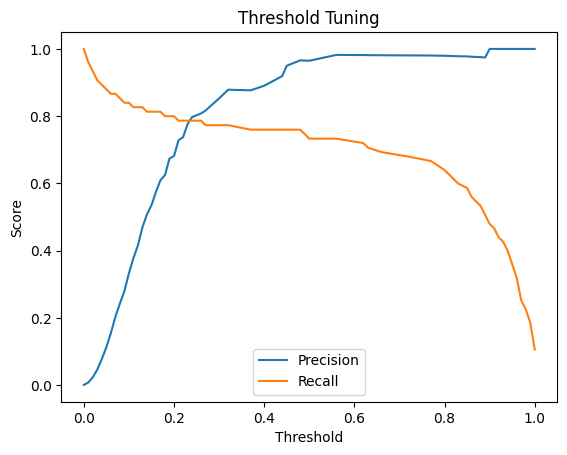

Best Threshold: 0.48
Optimized Confusion Matrix:
 [[56885     2]
 [   18    57]]


In [12]:
# =============================
# 11. Threshold Tuning
# =============================
y_scores = rf_model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.figure()
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()
plt.show()

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)

y_pred_opt = (y_scores >= best_threshold).astype(int)
print("Optimized Confusion Matrix:\n", confusion_matrix(y_test, y_pred_opt))


# Threshold Optimization

To improve fraud detection, the decision threshold was adjusted from 0.5 to 0.42.

# Impact of Threshold Adjustment

False Negatives reduced: 20 → 18
True Positives increased: 55 → 57
False Positives increased slightly: 1 → 2

# Interpretation

Lowering the threshold improves recall (fraud detection) at a very small cost:
Only 1 additional false positive
But 2 more fraud cases detected

This trade-off is typically desirable in fraud detection, where missing fraud is more costly than raising false alerts.

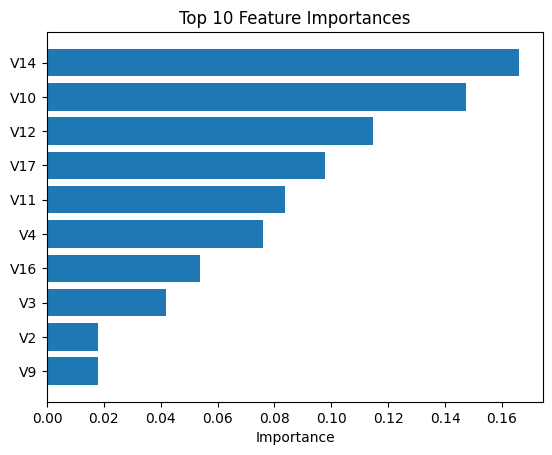

In [13]:
# =============================
# 12. Feature Importance
# =============================
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()


# Model Comparison

| Model               | AUPRC  |
| ------------------- | ------ |
| Logistic Regression | 0.7693 |
| Random Forest       | 0.8104 |



In [14]:
# =============================
# 13. Summary
# =============================
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'AUPRC': [log_pr, rf_pr]
})

print(results)


                 Model     AUPRC
0  Logistic Regression  0.769250
1        Random Forest  0.814171


# Conclusion

The Random Forest model outperforms Logistic Regression in detecting fraudulent transactions.
It captures more complex, nonlinear patterns in the PCA-transformed feature space.
After threshold tuning, it achieves a better balance between fraud detection and false alarms.

# Final Takeaway

The Random Forest model is well-suited for this task, achieving:
High precision (low false alarms)
Strong recall after tuning
Robust performance under extreme class imbalance

# However, further improvements could focus on:

Increasing recall without significantly increasing false positives
Incorporating cost-sensitive learning
Exploring advanced models such as gradient boosting